<!--
Copyright (c) 2020-2024 Key4hep-Project.

Licensed under the Apache License, Version 2.0.
-->

# Section 1: cell energy sum and energy resolution

Sums the energy of every calorimeter cell in each event, fits the peak with a Gaussian, and reports the sampling calorimeter's **energy resolution** σ/µ.

Uproot reads the EDM4hep file, Awkward Array and NumPy do the arithmetic, SciPy fits, and Matplotlib draws.

> **Hands-on 3** lives at the bottom of this notebook: change the sampling fraction and frequency in the compact file, re-run `ddsim`, and watch σ/µ move.

In [1]:
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from scipy.optimize import curve_fit

from drdcalo_tutorials import simplecalo1_input

# One blue for the data, one orange for the model, and three greys for everything
# that is not data. Keeping ink and marks apart is what stops a plot looking busy.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_SOFT, GRID, SURFACE = "#0b0b0b", "#52514e", "#dcdcd8", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelcolor": INK_SOFT,
    "ytick.labelcolor": INK_SOFT,
    "font.size": 11,
    "figure.dpi": 120,
})

## Open the event data

`simplecalo1_input()` prefers the `simplecalo1.root` you produced with

```bash
ddsim --steeringFile simplecalo1/sc1SteeringFile.py
```

and falls back to the bundled 10-event sample so that this notebook also runs straight after a clone. `SIMPLECALO1_FILE` overrides both.

In [2]:
input_file = simplecalo1_input()
COLLECTION = "simplecaloRO"

events = uproot.open(input_file, handler=uproot.MultithreadedFileSource)["events"]
n_events = events.num_entries
print(f"Reading {n_events} events from {input_file}")

Reading 500 events from /home/j/jbeirer/BNLSchoolTest/SoftwareTutorials/DD4hepTutorials/simplecalo.root


## Sum the cells, event by event

Uproot hands back one nested list of cell energies per event. Summing on `axis=1` collapses each of those lists to a single number and keeps the event boundary, so no Python loop over events is needed.

In [3]:
cell_energies = events[f"{COLLECTION}/{COLLECTION}.energy"].array(library="ak")
total_energy = ak.to_numpy(ak.sum(cell_energies, axis=1)).astype(float)

if total_energy.size == 0:
    raise SystemExit(f"No events found in {input_file}")

print(f"{ak.sum(ak.num(cell_energies))} cells in {n_events} events")
print(f"Mean energy sum: {total_energy.mean():.4f} GeV")

23215 cells in 500 events
Mean energy sum: 1.4995 GeV


## Histogram and Gaussian fit

The binning follows the data instead of a fixed axis: the energy scale depends on the sampling fraction, which Hands-on 3 invites you to change.

Only the core of the peak is fitted — the highest bin ± 3 RMS — so that the tails, where a shower leaked out of the calorimeter, do not pull the width. Bin uncertainties are Poisson, which is what makes the reported σ uncertainty and the χ² meaningful.

In [4]:
BINS = 50


def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


# The binning follows the data rather than a fixed 0-4 GeV axis: the energy scale
# depends on the sampling fraction, which Hands-on 3 invites you to change, and a
# range anchored at zero would waste most of the plot on an empty region.
margin = 0.05 * (total_energy.max() - total_energy.min()) or 1.0
counts, edges = np.histogram(
    total_energy, bins=BINS, range=(total_energy.min() - margin, total_energy.max() + margin)
)
centres = 0.5 * (edges[:-1] + edges[1:])

peak = centres[np.argmax(counts)]
half_window = 3 * total_energy.std()

# Empty bins carry no Poisson weight, so they are left out of the fit rather than
# given an arbitrary uncertainty.
in_fit = (np.abs(centres - peak) <= half_window) & (counts > 0)

popt, pcov = curve_fit(
    gaussian,
    centres[in_fit],
    counts[in_fit],
    p0=(counts.max(), peak, total_energy.std()),
    sigma=np.sqrt(counts[in_fit]),
    absolute_sigma=True,
)

amplitude, mean, sigma = popt
sigma = abs(sigma)  # the Gaussian is symmetric in sigma, so the fit may return either sign
mean_error, sigma_error = np.sqrt(np.diag(pcov))[1:]

pulls = (counts[in_fit] - gaussian(centres[in_fit], *popt)) / np.sqrt(counts[in_fit])
chi2, ndf = float(np.sum(pulls**2)), int(in_fit.sum() - len(popt))
resolution = sigma / mean

## Result

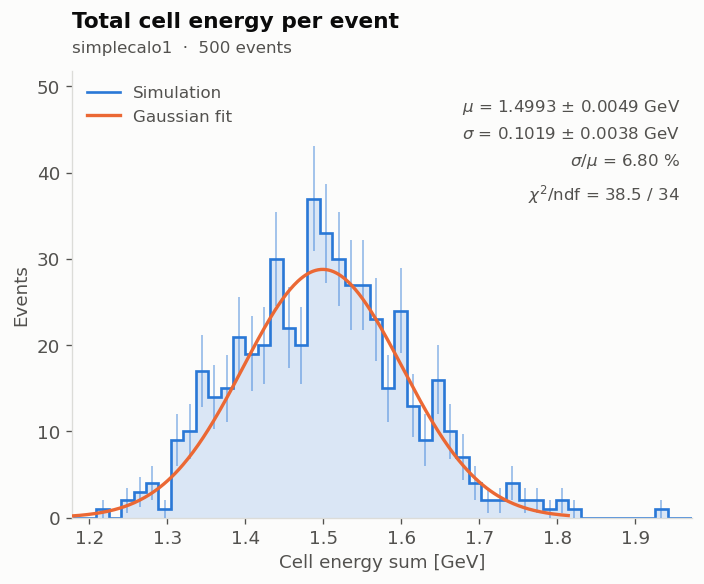

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

# The distribution: a soft fill for the shape, a crisp outline for the edges, and
# Poisson bars so the reader can see what the fit was actually weighted by
ax.stairs(counts, edges, fill=True, facecolor=BLUE, alpha=0.16, edgecolor="none", zorder=1)
ax.stairs(counts, edges, color=BLUE, linewidth=1.6, label="Simulation", zorder=2)
ax.errorbar(centres, counts, yerr=np.sqrt(counts), fmt="none",
            ecolor=BLUE, elinewidth=1.0, alpha=0.5, zorder=3)

# Drawing the curve over the fit window only, so that where it stops is also
# where the fit stopped looking
fit_curve_x = np.linspace(peak - half_window, peak + half_window, 400)
ax.plot(fit_curve_x, gaussian(fit_curve_x, *popt), color=ORANGE, linewidth=2,
        label="Gaussian fit", zorder=4)

ax.set_title("Total cell energy per event", loc="left", fontsize=13,
             fontweight="semibold", pad=26)
ax.text(0, 1.04, f"simplecalo1  ·  {n_events} events", transform=ax.transAxes,
        fontsize=10, color=INK_SOFT)

ax.text(0.98, 0.94,
        "\n".join([
            rf"$\mu$ = {mean:.4f} $\pm$ {mean_error:.4f} GeV",
            rf"$\sigma$ = {sigma:.4f} $\pm$ {sigma_error:.4f} GeV",
            rf"$\sigma/\mu$ = {100 * resolution:.2f} %",
            rf"$\chi^2$/ndf = {chi2:.1f} / {ndf}",
        ]),
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color=INK_SOFT, linespacing=1.7)

ax.set_xlabel("Cell energy sum [GeV]")
ax.set_ylabel("Events")
ax.set_xlim(edges[0], edges[-1])
# Headroom, so that the legend and the fit results never sit on top of the peak
ax.set_ylim(0, 1.4 * counts.max())
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper left", fontsize=10, labelcolor=INK_SOFT)

fig.tight_layout()

In [6]:
print(f"Fitted mean        {mean:.4f} +/- {mean_error:.4f} GeV")
print(f"Fitted sigma       {sigma:.4f} +/- {sigma_error:.4f} GeV")
print(f"chi2 / ndf         {chi2:.1f} / {ndf}")
print()
print(f"Energy resolution  sigma/mean = {100 * resolution:.2f} %")

Fitted mean        1.4993 +/- 0.0049 GeV
Fitted sigma       0.1019 +/- 0.0038 GeV
chi2 / ndf         38.5 / 34

Energy resolution  sigma/mean = 6.80 %


## Hands-on 3 — sampling fraction and sampling frequency

The number above is the whole point of the exercise. Change the calorimeter in `simplecalo1/compact/simplecalo1.xml` and see how it responds:

- **Sampling fraction** — the share of a layer that is active. Move `AbsLayerZ` and `SensLayerZ` while keeping `CaloLayerZ = AbsLayerZ + SensLayerZ`. A thicker active layer collects more of the shower, so the visible energy grows.
- **Sampling frequency** — how finely the shower is sampled. Shrink `CaloLayerZ` and raise `LayersNumber` so the calorimeter keeps its total depth. More, thinner layers sample the shower more often.

Then re-run the simulation and this notebook:

```bash
ddsim --steeringFile simplecalo1/sc1SteeringFile.py
```

Sampling calorimeters are dominated by sampling fluctuations, so σ/µ should improve roughly as the square root of the sampling frequency. Watch the fitted µ as well: it tells you how much of the 50 GeV actually ends up in the active material.

> Nothing is hard-coded to the default geometry — the histogram range follows the data — so the fit keeps working as the energy scale moves.